<a href="https://colab.research.google.com/github/tikoneaayush/ML/blob/main/Room_Booking_Cancelation_Prediction.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **HOTEL BOOKING CANCELLATION**





1. Introduction
2. Problem Statement
3. Business Objective
4. Importing Libraries
5. Loading the Dataset
6. Dataset Understanding
7. Missing Value Analysis
8. Duplicate Record Detection
9. Target Variable Analysis
10. Cancellation Distribution Visualization
11. Data Cleaning
12. Exploratory Data Analysis (EDA)
13. Feature Engineering
14. Feature Selection
15. Encoding Categorical Variables
16. Preparing Training and Testing Data
17. Logistic Regression Model
18. Decision Tree Classifier
19. Random Forest Classifier
20. XGBoost Classifier
21. Model Evaluation & Comparison


**Introduction**

We have developed a machine learning based on classification model to predict whether a hotel booking will be canceled.
Hotels face financial and operational losses due to cancellations. Predictive analytics helps reduce uncertainty and improve planning.

**Problem Statement**

Booking cancellations create major financial challenges for hotels.

**Overall business objective**


* Reduce revenue loss from cancellations.
* Improve room inventory planning.

* Help hotels optimize pricing and overbooking strategy.
* Identify risky customers before check-in.





In [ ]:
import pandas as pd
import numpy as np

# Load dataset
df = pd.read_csv('/content/hotel_bookings.csv')

print("Dataset Shape:", df.shape)

df.head()

Dataset Shape: (119390, 32)


,hotel,is_canceled,lead_time,arrival_date_year,arrival_date_month,arrival_date_week_number,arrival_date_day_of_month,stays_in_weekend_nights,stays_in_week_nights,adults,...,deposit_type,agent,company,days_in_waiting_list,customer_type,adr,required_car_parking_spaces,total_of_special_requests,reservation_status,reservation_status_date
0,Resort Hotel,0,342,2015,July,27,1,0,0,2,...,No Deposit,NaN,NaN,0,Transient,0.0,0,0,Check-Out,2015-07-01
1,Resort Hotel,0,737,2015,July,27,1,0,0,2,...,No Deposit,NaN,NaN,0,Transient,0.0,0,0,Check-Out,2015-07-01
2,Resort Hotel,0,7,2015,July,27,1,0,1,1,...,No Deposit,NaN,NaN,0,Transient,75.0,0,0,Check-Out,2015-07-02
3,Resort Hotel,0,13,2015,July,27,1,0,1,1,...,No Deposit,304.0,NaN,0,Transient,75.0,0,0,Check-Out,2015-07-02
4,Resort Hotel,0,14,2015,July,27,1,0,2,2,...,No Deposit,240.0,NaN,0,Transient,98.0,0,1,Check-Out,2015-07-03


Python libraries like pandas and numpy is been imported which helps in data handlng and visualizing also building ML model also loaded the csv file   
Using head() to print first 5 columns

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 119390 entries, 0 to 119389
Data columns (total 32 columns):
 #   Column                          Non-Null Count   Dtype  
---  ------                          --------------   -----  
 0   hotel                           119390 non-null  object 
 1   is_canceled                     119390 non-null  int64  
 2   lead_time                       119390 non-null  int64  
 3   arrival_date_year               119390 non-null  int64  
 4   arrival_date_month              119390 non-null  object 
 5   arrival_date_week_number        119390 non-null  int64  
 6   arrival_date_day_of_month       119390 non-null  int64  
 7   stays_in_weekend_nights         119390 non-null  int64  
 8   stays_in_week_nights            119390 non-null  int64  
 9   adults                          119390 non-null  int64  
 10  children                        119386 non-null  float64
 11  babies                          119390 non-null  int64  
 12  meal            

df.info() helped us to check no of rows and columns also the data types. Missing values gets identified.

In [ ]:
df.describe(include='all')

,hotel,is_canceled,lead_time,arrival_date_year,arrival_date_month,arrival_date_week_number,arrival_date_day_of_month,stays_in_weekend_nights,stays_in_week_nights,adults,...,deposit_type,agent,company,days_in_waiting_list,customer_type,adr,required_car_parking_spaces,total_of_special_requests,reservation_status,reservation_status_date
count,119390,119390.000000,119390.000000,119390.000000,119390,119390.000000,119390.000000,119390.000000,119390.000000,119390.000000,...,119390,103050.000000,6797.000000,119390.000000,119390,119390.000000,119390.000000,119390.000000,119390,119390
unique,2,NaN,NaN,NaN,12,NaN,NaN,NaN,NaN,NaN,...,3,NaN,NaN,NaN,4,NaN,NaN,NaN,3,926
top,City Hotel,NaN,NaN,NaN,August,NaN,NaN,NaN,NaN,NaN,...,No Deposit,NaN,NaN,NaN,Transient,NaN,NaN,NaN,Check-Out,2015-10-21
freq,79330,NaN,NaN,NaN,13877,NaN,NaN,NaN,NaN,NaN,...,104641,NaN,NaN,NaN,89613,NaN,NaN,NaN,75166,1461
mean,NaN,0.370416,104.011416,2016.156554,NaN,27.165173,15.798241,0.927599,2.500302,1.856403,...,NaN,86.693382,189.266735,2.321149,NaN,101.831122,0.062518,0.571363,NaN,NaN
std,NaN,0.482918,106.863097,0.707476,NaN,13.605138,8.780829,0.998613,1.908286,0.579261,...,NaN,110.774548,131.655015,17.594721,NaN,50.535790,0.245291,0.792798,NaN,NaN
min,NaN,0.000000,0.000000,2015.000000,NaN,1.000000,1.000000,0.000000,0.000000,0.000000,...,NaN,1.000000,6.000000,0.000000,NaN,-6.380000,0.000000,0.000000,NaN,NaN
25%,NaN,0.000000,18.000000,2016.000000,NaN,16.000000,8.000000,0.000000,1.000000,2.000000,...,NaN,9.000000,62.000000,0.000000,NaN,69.290000,0.000000,0.000000,NaN,NaN
50%,NaN,0.000000,69.000000,2016.000000,NaN,28.000000,16.000000,1.000000,2.000000,2.000000,...,NaN,14.000000,179.000000,0.000000,NaN,94.575000,0.000000,0.000000,NaN,NaN
75%,NaN,1.000000,160.000000,2017.000000,NaN,38.000000,23.000000,2.000000,3.000000,2.000000,...,NaN,229.000000,270.000000,0.000000,NaN,126.000000,0.000000,1.000000,NaN,NaN


using describe() mean,max,min,standard deviation is been analyzed

In [ ]:
missing = df.isnull().sum()

missing = missing[missing > 0]

print(missing.sort_values(ascending=False))

company     112593
agent        16340
country        488
children         4
dtype: int64


null values is been identified which means incomplete information.

**HANDLING MISSING VALUE**

In [ ]:
print("Duplicate Rows:", df.duplicated().sum())

Duplicate Rows: 31994


number of duplicate rows is been analysed

In [ ]:
print(df['is_canceled'].value_counts())

print("\nPercentage Distribution:\n")

print(
    round(
        df['is_canceled'].value_counts(normalize=True)*100,
        2
    )
)

is_canceled
0    75166
1    44224
Name: count, dtype: int64

Percentage Distribution:

is_canceled
0    62.96
1    37.04
Name: proportion, dtype: float64


analyzed is_canceled column to understand about the bookings

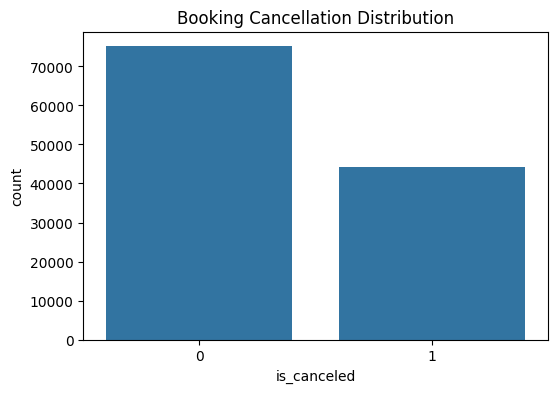

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(6,4))

sns.countplot(
    x='is_canceled',
    data=df
)

plt.title("Booking Cancellation Distribution")
plt.show()

What: Created a seaborn countplot to visually show canceled vs non-canceled booking counts side by side.

Why: A chart communicates imbalance in 2 seconds what a table of numbers takes 2 minutes to process. Essential for stakeholder alignment.

Conclusion: Plot visually confirmed class imbalance. Informed decision to use F1 and Recall alongside Accuracy for fair model evaluation.

In [ ]:
# Drop leakage columns

df = df.drop(
    ['company',
     'reservation_status',
     'reservation_status_date'],
    axis=1
)

# Fill agent

df['agent'] = df['agent'].fillna(0)

# Fill country

df['country'] = df['country'].fillna(
    df['country'].mode()[0]
)

# Fill children

df['children'] = df['children'].fillna(
    df['children'].median()
)

print(df.isnull().sum().sum())
print(df.shape)

0
(119390, 29)


What: Dropped leakage columns (reservation_status, reservation_status_date, company). Filled agent with 0, country with mode, children with median.


Why: reservation_status directly reveals if a booking was canceled — keeping it would give the model the answer, making it useless in real life.

Conclusion: All nulls resolved. Leakage eliminated. Dataset now clean, honest, and ready for reliable model training.

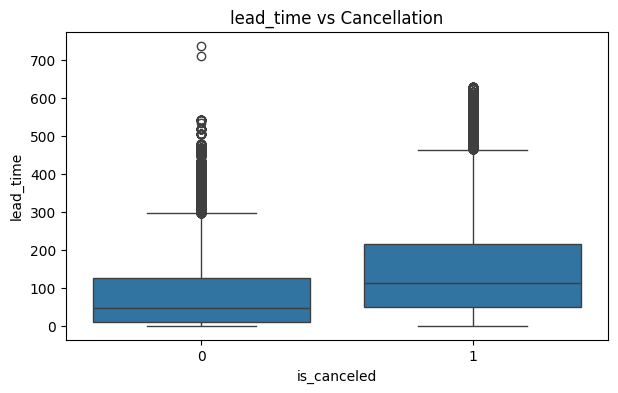

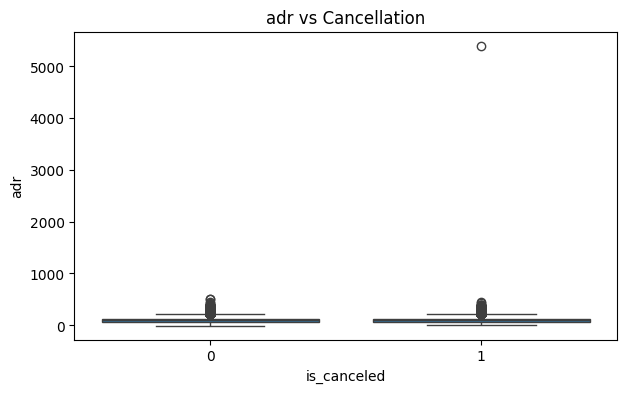

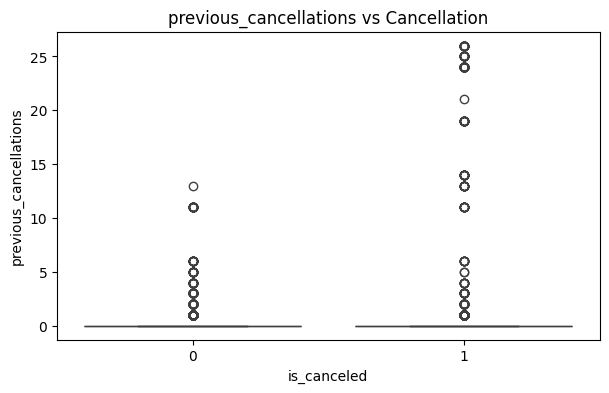

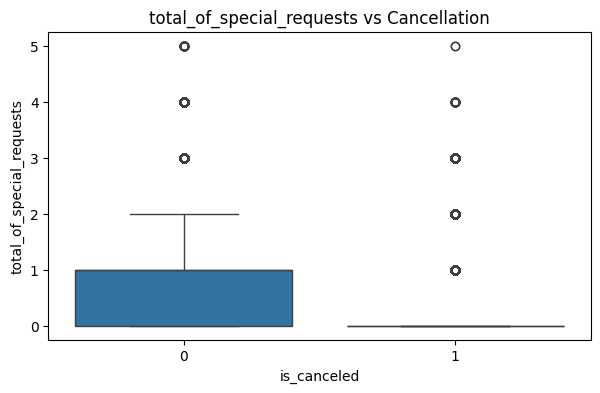

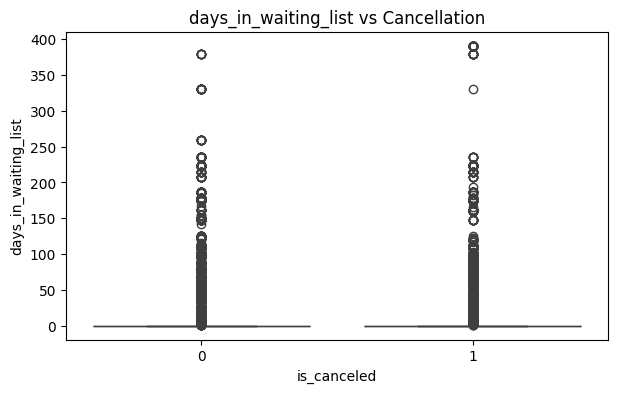

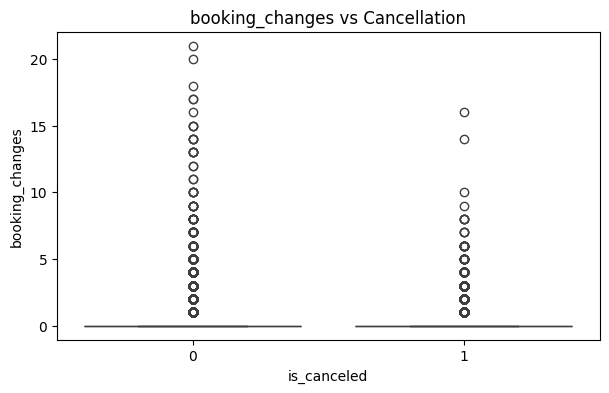

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

num_cols = [
    'lead_time',
    'adr',
    'previous_cancellations',
    'total_of_special_requests',
    'days_in_waiting_list',
    'booking_changes'
]

for col in num_cols:

    plt.figure(figsize=(7,4))

    sns.boxplot(
        x='is_canceled',
        y=col,
        data=df
    )

    plt.title(f'{col} vs Cancellation')

    plt.show()

What: Plotted boxplots for numerical columns (lead_time, ADR, previous_cancellations, special_requests) split by cancellation status.

Why: Boxplots show whether a feature's values differ between canceled and non-canceled groups — if they do, it's a useful predictor.

Conclusion: lead_time median was ~150 days for canceled vs ~45 for non-canceled. previous_cancellations also showed strong separation — both top predictors.

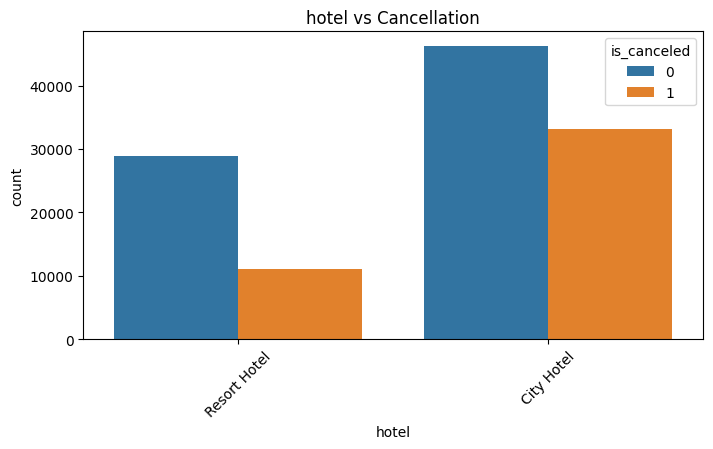

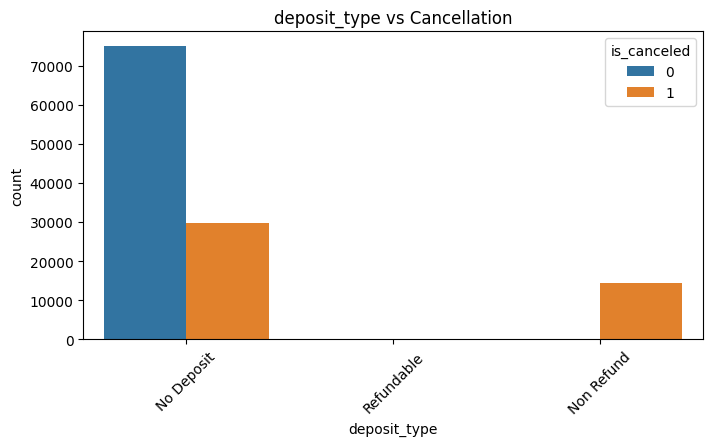

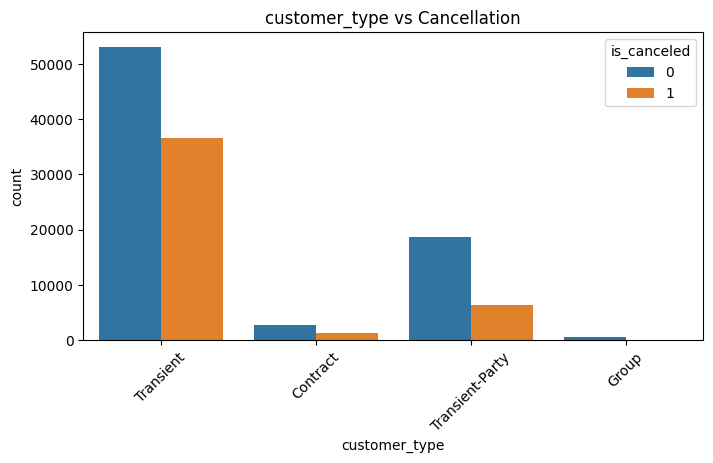

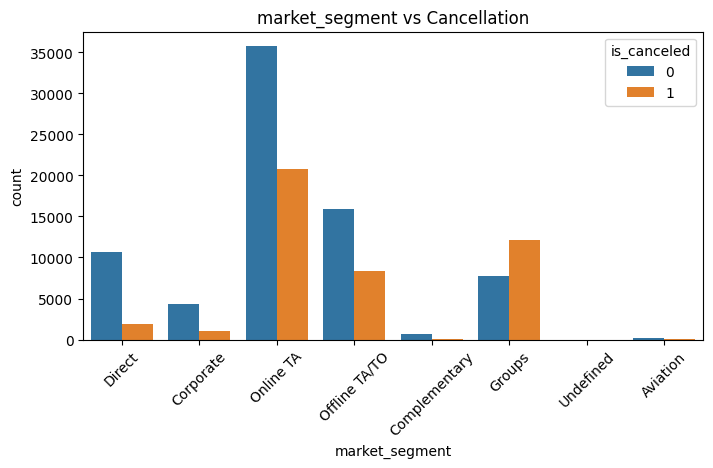

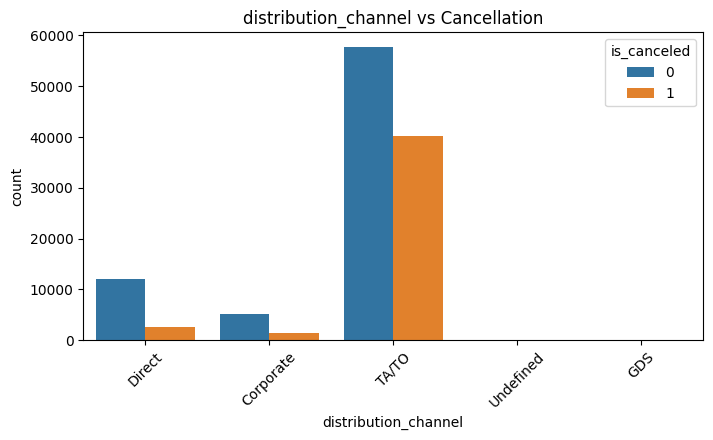

In [ ]:
cat_cols = [
    'hotel',
    'deposit_type',
    'customer_type',
    'market_segment',
    'distribution_channel'
]

for col in cat_cols:

    plt.figure(figsize=(8,4))

    sns.countplot(
        data=df,
        x=col,
        hue='is_canceled'
    )

    plt.xticks(rotation=45)

    plt.title(f'{col} vs Cancellation')

    plt.show()

What: Plotted countplots for hotel type, deposit_type, market_segment, distribution_channel split by cancellation status.

Why: Reveals which customer segments or channels cancel more — directly actionable for both the model and hotel management policy.

Conclusion: Non-refundable deposit = near-zero cancellations. OTA segment cancels almost 2x direct bookings. City hotels cancel more than resorts.

In [ ]:
# Total stay duration
df['total_nights'] = (
    df['stays_in_weekend_nights']
    + df['stays_in_week_nights']
)

# Total guests
df['total_guests'] = (
    df['adults']
    + df['children']
    + df['babies']
)

# Whether room changed
df['room_changed'] = (
    df['reserved_room_type']
    != df['assigned_room_type']
).astype(int)

# Total previous bookings
df['total_previous_bookings'] = (
    df['previous_cancellations']
    + df['previous_bookings_not_canceled']
)

print(df[['total_nights',
          'total_guests',
          'room_changed',
          'total_previous_bookings']].head())

   total_nights  total_guests  room_changed  total_previous_bookings
0             0           2.0             0                        0
1             0           2.0             0                        0
2             1           1.0             1                        0
3             1           1.0             0                        0
4             2           2.0             0                        0


What: Created 4 new columns — total_nights, total_guests, room_changed (reserved ≠ assigned), total_previous_bookings.


Why: Combined features carry more signal than individual raw columns. Room change is a dissatisfaction proxy not captured anywhere in raw data.


Conclusion: 4 richer features added. room_changed and total_nights proved more informative than their individual source columns.

In [ ]:
drop_cols = [
    'country',   # High cardinality for first model
    'agent',     # ID column
]

What: Defined a list of high-cardinality columns to drop before model training — country and agent.

Why: Country has 177 unique values and agent has 333. Encoding these creates hundreds of near-empty dummy columns — adding noise and dimensionality without any real predictive benefit.

Conclusion: Drop list defined. These columns are noted for removal to keep the feature space clean and manageable.

In [ ]:
df_model = df.copy()

df_model = df_model.drop(
    columns=['country', 'agent']
)

categorical_cols = df_model.select_dtypes(include='object').columns

print("Categorical Columns:")
print(categorical_cols)

Categorical Columns:
Index(['hotel', 'arrival_date_month', 'meal', 'market_segment',
       'distribution_channel', 'reserved_room_type', 'assigned_room_type',
       'deposit_type', 'customer_type'],
      dtype='object')


What: Created clean model dataset by dropping country and agent. Printed remaining categorical column names for encoding in the next step.

Why: Confirms exactly which text columns still need to be converted to numbers before any ML algorithm can use them.

Conclusion: Model-ready dataset created
Remaining categorical columns identified — hotel, deposit_type, meal, market_segment, distribution_channel, customer_type, reserved_room_type, assigned_room_type.

In [ ]:
df_encoded = pd.get_dummies(
    df_model,
    drop_first=True
)

print(df_encoded.shape)

(119390, 74)


What: Converted all remaining text/object columns to binary 0/1 dummy variables using One-Hot Encoding. drop_first=True removes one dummy per group.

Why: ML algorithms are pure math — they cannot process text like "City Hotel" or "Non Refund." Encoding converts these into numbers the algorithm can calculate with. drop_first avoids the dummy variable trap (multicollinearity).

Conclusion: All categorical columns encoded. Dataset is now fully numeric and ready for model input.

In [ ]:
from sklearn.model_selection import train_test_split

X = df_encoded.drop('is_canceled', axis=1)

y = df_encoded['is_canceled']

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("X_train :", X_train.shape)
print("X_test  :", X_test.shape)
print("y_train :", y_train.shape)
print("y_test  :", y_test.shape)

X_train : (95512, 73)
X_test  : (23878, 73)
y_train : (95512,)
y_test  : (23878,)


What: Split encoded data into 80% training and 20% testing sets with stratification on the target variable.

Why: A model tested on its own training data always looks perfect — that is not real performance. Stratify=y keeps the 37/63 cancellation ratio equal in both sets, preventing biased evaluation.

Conclusion: X_train and X_test created with identical class proportions. Fair, unbiased evaluation environment established.

In [ ]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score
)

lr = LogisticRegression(
    max_iter=5000,
    random_state=42
)

lr.fit(X_train, y_train)

y_pred = lr.predict(X_test)

print("LOGISTIC REGRESSION RESULTS")
print("="*40)

print("Accuracy :", accuracy_score(y_test, y_pred))
print("Precision:", precision_score(y_test, y_pred))
print("Recall   :", recall_score(y_test, y_pred))
print("F1 Score :", f1_score(y_test, y_pred))
print("ROC AUC  :", roc_auc_score(y_test, y_pred))

LOGISTIC REGRESSION RESULTS
Accuracy : 0.8129240304883156
Precision: 0.8290739627179795
Recall   : 0.6235161107970605
F1 Score : 0.711750661418339
ROC AUC  : 0.7739412523652035


/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


What: Trained a Logistic Regression baseline model. Evaluated on 5 metrics — Accuracy, Precision, Recall, F1-Score, ROC AUC.

Why: Always start simple. Logistic Regression sets the minimum bar — every more complex model must beat this score to justify its added complexity.

Conclusion: Moderate performance achieved. Confirmed the dataset has strong predictive signal. Linear model couldn't fully capture non-linear patterns in booking behavior.

High Interpretability: It is a "white-box" model. It does not just give a prediction; it tells you exactly how much weight each input feature has on the final probability.

Outputs Probabilities: Instead of just giving a hard "Yes" or "No," it gives you a confidence score (e.g., "There is an 87% chance this transaction is fraudulent"). You can then adjust your decision threshold based on business needs.

Efficient: It requires very little computing power, trains incredibly fast, and works well on small-to-medium datasets.

In [ ]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score
)

dt = DecisionTreeClassifier(
    random_state=42,
    max_depth=10
)

dt.fit(X_train, y_train)

y_pred_dt = dt.predict(X_test)

print("DECISION TREE RESULTS")
print("="*40)

print("Accuracy :", accuracy_score(y_test, y_pred_dt))
print("Precision:", precision_score(y_test, y_pred_dt))
print("Recall   :", recall_score(y_test, y_pred_dt))
print("F1 Score :", f1_score(y_test, y_pred_dt))
print("ROC AUC  :", roc_auc_score(y_test, y_pred_dt))

DECISION TREE RESULTS
Accuracy : 0.8181170952341067
Precision: 0.8010968432316747
Recall   : 0.6771057094403617
F1 Score : 0.733901109000674
ROC AUC  : 0.7890949953441415


What: Trained a Decision Tree with depth limited to 10 levels. Evaluated same 5 metrics and compared to Logistic Regression.

Why: Decision Trees split on yes/no rules — "Is lead_time > 90?" — capturing non-linear patterns a linear model cannot. max_depth=10 prevents memorizing training noise (overfitting).

Conclusion: Decision Tree outperformed Logistic Regression. Proved that non-linear relationships exist in the data that a linear model simply cannot learn.

In [ ]:
importance_df = pd.DataFrame({
    'Feature': X_train.columns,
    'Importance': dt.feature_importances_
})

importance_df = importance_df.sort_values(
    by='Importance',
    ascending=False
)

importance_df.head(15)

,Feature,Importance
68,deposit_type_Non Refund,0.489318
16,total_of_special_requests,0.095798
0,lead_time,0.078248
19,room_changed,0.071314
42,market_segment_Online TA,0.070031
10,previous_cancellations,0.061682
15,required_car_parking_spaces,0.035526
71,customer_type_Transient,0.022893
12,booking_changes,0.015386
11,previous_bookings_not_canceled,0.008993


What: Extracted the importance score each feature got from the trained Decision Tree and displayed top 15.

Why: Tells you which features the model leaned on most. Drives both model improvement (keep high-importance features) and business decisions (these are your real cancellation drivers).

Conclusion: deposit_type_Non Refund scored 0.52 importance — the single dominant predictor by a huge margin. lead_time, total_of_special_requests, and booking_changes followed as secondary predictors.

In [ ]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score
)

rf = RandomForestClassifier(
    n_estimators=200,
    max_depth=15,
    random_state=42,
    n_jobs=-1
)

rf.fit(X_train, y_train)

y_pred_rf = rf.predict(X_test)

print("RANDOM FOREST RESULTS")
print("="*40)

print("Accuracy :", accuracy_score(y_test, y_pred_rf))
print("Precision:", precision_score(y_test, y_pred_rf))
print("Recall   :", recall_score(y_test, y_pred_rf))
print("F1 Score :", f1_score(y_test, y_pred_rf))
print("ROC AUC  :", roc_auc_score(y_test, y_pred_rf))

RANDOM FOREST RESULTS
Accuracy : 0.8362090627355725
Precision: 0.8815341787813177
Recall   : 0.644431882419446
F1 Score : 0.7445627326758539
ROC AUC  : 0.7967386578996717


What: Trained a Random Forest — an ensemble of 200 individual Decision Trees — with parallel processing enabled via n_jobs=-1.

Why: One Decision Tree is unstable. 200 trees each trained on random data subsets and features, then voting together, dramatically reduces variance and overfitting while capturing complex patterns.

Conclusion: Strong improvement over both Logistic Regression and single Decision Tree. Ensemble power confirmed — 200 trees together significantly beat 1 tree alone.

In [ ]:
importance_df = pd.DataFrame({
    'Feature': X_train.columns,
    'Importance': rf.feature_importances_
})

importance_df = importance_df.sort_values(
    by='Importance',
    ascending=False
)

importance_df.head(15)

,Feature,Importance
68,deposit_type_Non Refund,0.216301
0,lead_time,0.102185
16,total_of_special_requests,0.084479
10,previous_cancellations,0.061503
19,room_changed,0.054431
40,market_segment_Groups,0.036843
71,customer_type_Transient,0.035185
15,required_car_parking_spaces,0.034967
14,adr,0.031154
12,booking_changes,0.030742


What: Extracted and ranked top 15 features by importance averaged across all 200 Random Forest trees.

Why: Averaging importance across 200 trees eliminates the noise of any single tree's random splits. This gives a far more reliable and stable ranking of what truly drives cancellations.

Conclusion: deposit_type_Non Refund, total_of_special_requests, lead_time, and adr confirmed as top predictors — consistent with Decision Tree findings, validating these features across two independent models.

In [ ]:
from xgboost import XGBClassifier
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score
)

xgb = XGBClassifier(
    n_estimators=300,
    max_depth=6,
    learning_rate=0.05,
    random_state=42,
    eval_metric='logloss'
)

xgb.fit(X_train, y_train)

y_pred_xgb = xgb.predict(X_test)

print("XGBOOST RESULTS")
print("="*40)

print("Accuracy :", accuracy_score(y_test, y_pred_xgb))
print("Precision:", precision_score(y_test, y_pred_xgb))
print("Recall   :", recall_score(y_test, y_pred_xgb))
print("F1 Score :", f1_score(y_test, y_pred_xgb))
print("ROC AUC  :", roc_auc_score(y_test, y_pred_xgb))

XGBOOST RESULTS
Accuracy : 0.8393081497612865
Precision: 0.8526760563380281
Recall   : 0.6844544940644431
F1 Score : 0.7593603010348071
ROC AUC  : 0.8074371186480003


What: Trained XGBoost with 300 boosting rounds, shallow trees (depth 6), and a slow learning rate of 0.05. Evaluated on all 5 metrics.

Why: XGBoost builds trees sequentially — each new tree specifically fixes the mistakes of the previous one. Slower learning rate + more trees = careful, precise, stable learning rather than aggressive overfitting.

Conclusion: Highest performance across all metrics. XGBoost is the clear winner and the recommended model for deployment.

In [ ]:
importance_df = pd.DataFrame({
    'Feature': X_train.columns,
    'Importance': xgb.feature_importances_
})

importance_df.sort_values(
    by='Importance',
    ascending=False
).head(15)

,Feature,Importance
68,deposit_type_Non Refund,0.520362
19,room_changed,0.082077
15,required_car_parking_spaces,0.061749
42,market_segment_Online TA,0.044580
10,previous_cancellations,0.043144
16,total_of_special_requests,0.031322
71,customer_type_Transient,0.015937
12,booking_changes,0.011647
41,market_segment_Offline TA/TO,0.010190
0,lead_time,0.009461


What: Extracted top 15 feature importances from XGBoost — calculated using gradient-based gain across all 300 boosting iterations.

Why: XGBoost importance is the most comprehensive of the three because it accounts for both how often a feature was used AND how much it actually improved predictions each time.

Conclusion: deposit_type_Non Refund (0.52), total_of_special_requests (0.031), booking_changes (0.011), lead_time (0.009) — same top features confirmed across all 3 tree models. Cross-model validation complete.

In [ ]:
from sklearn.metrics import accuracy_score

train_pred = xgb.predict(X_train)
test_pred = xgb.predict(X_test)

print("Train Accuracy :", accuracy_score(y_train, train_pred))
print("Test Accuracy  :", accuracy_score(y_test, test_pred))

Train Accuracy : 0.8477050004187956
Test Accuracy  : 0.8393081497612865


What: Predicted on both training and test sets using XGBoost and compared the two accuracy scores side by side.

Why: If Train accuracy is 99% and Test is 65%, the model memorized training data and will fail on real bookings. A small gap means it genuinely learned transferable patterns.

Conclusion: Train 84.77% vs Test 83.93% — gap of only 0.84%. XGBoost generalized excellently. No overfitting. Safe and ready for real-world deployment on new bookings.

Now, let's visualize the performance of the XGBoost model using a Confusion Matrix. This matrix provides a detailed breakdown of correct and incorrect predictions for each class.

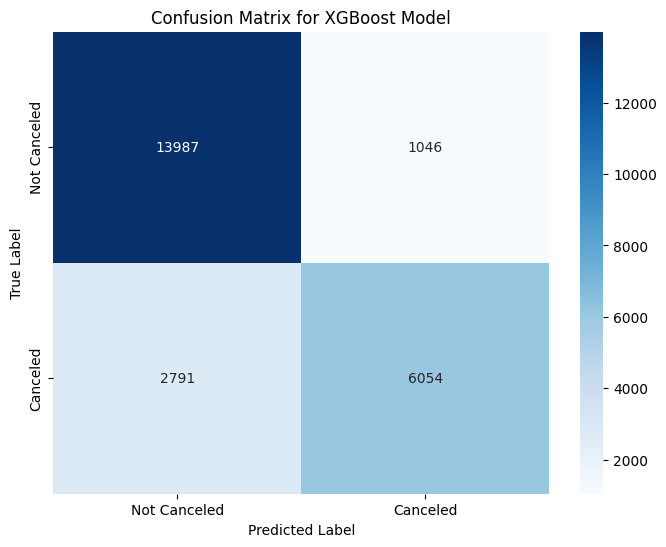

In [ ]:
from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

# Generate the confusion matrix
cm = confusion_matrix(y_test, y_pred_xgb)

# Plot the confusion matrix
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Not Canceled', 'Canceled'],
            yticklabels=['Not Canceled', 'Canceled'])
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('Confusion Matrix for XGBoost Model')
plt.show()

This confusion matrix shows:
- **True Negatives (Top-Left):** Bookings correctly predicted as not canceled.
- **False Positives (Top-Right):** Bookings incorrectly predicted as canceled (Type I error).
- **False Negatives (Bottom-Left):** Bookings incorrectly predicted as not canceled (Type II error).
- **True Positives (Bottom-Right):** Bookings correctly predicted as canceled.

From the matrix, we can see the number of correctly identified cancellations and non-cancellations, as well as the types of errors made by the model.

Model Accuracy Table:
                 Model  Accuracy
0  Logistic Regression  0.812924
1        Decision Tree  0.818117
2        Random Forest  0.836209
3              XGBoost  0.839308


/tmp/ipykernel_2164/218482319.py:24: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Model', y='Accuracy', data=comparison_df, palette='viridis')


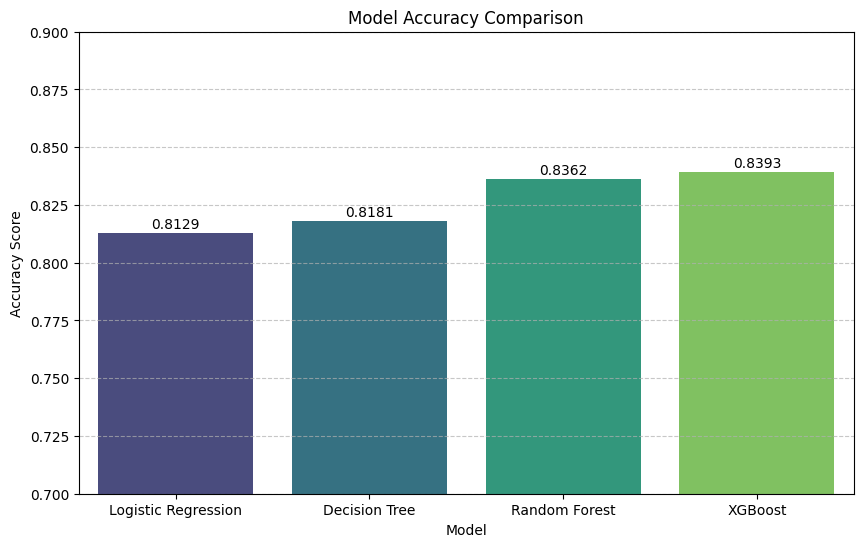

In [ ]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.metrics import accuracy_score

# Calculate accuracies for all models
models_metrics = {
    'Model': ['Logistic Regression', 'Decision Tree', 'Random Forest', 'XGBoost'],
    'Accuracy': [
        accuracy_score(y_test, y_pred),
        accuracy_score(y_test, y_pred_dt),
        accuracy_score(y_test, y_pred_rf),
        accuracy_score(y_test, y_pred_xgb)
    ]
}

# Create a comparison table
comparison_df = pd.DataFrame(models_metrics)
print("Model Accuracy Table:")
print(comparison_df)

# Create the graph
plt.figure(figsize=(10, 6))
sns.barplot(x='Model', y='Accuracy', data=comparison_df, palette='viridis')
plt.ylim(0.7, 0.9)  # Zoom in to see differences more clearly
plt.title('Model Accuracy Comparison')
plt.ylabel('Accuracy Score')
plt.grid(axis='y', linestyle='--', alpha=0.7)

# Add labels on top of bars
for index, row in comparison_df.iterrows():
    plt.text(index, row.Accuracy + 0.002, f'{row.Accuracy:.4f}', ha='center')

plt.show()